In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF


from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans

In [26]:
df=pd.read_csv("corpus_zola_paquets_lemm.csv") # Chargement du DataFrame nettoyé à partir du fichier CSV

In [27]:
df.head()

,nom_fichier,id_paquet,phrases_paquet,phrases_lemm
0,1893_20_Le_docteur_Pascal._clean.txt,0,Dans la chaleur de l’ardente après-midi de jui...,chaleur ardent après-midi juillet salle volet ...
1,1893_20_Le_docteur_Pascal._clean.txt,1,"Mais il dut prendre une chaise, la planche du ...",chaise planche haut haut grand taille planche ...
2,1893_20_Le_docteur_Pascal._clean.txt,2,"Oh! Monsieur, la religion n’a jamais fait de m...",monsieur religion mal idée sûr silence diverge...
3,1893_20_Le_docteur_Pascal._clean.txt,3,"De face, dans son visage séché, ses yeux garda...",face visage oeil flamme joli sourir grand-mère...
4,1893_20_Le_docteur_Pascal._clean.txt,4,s’écria la jeune fille. Mais elle était lancée...,jeune fille bon femme fond faubourg pile mort ...


In [28]:
vectorizer = TfidfVectorizer( 
    min_df=3,
    max_df=0.8
    )
# min_df=5 : Ignorer les termes qui apparaissent dans moins de 3 segments, car ils sont considérés comme peu informatifs.
# max_df=0.8 : Ignorer les termes qui apparaissent dans plus de 80% des segments, car ils sont trop fréquents et ne contribuent pas à différencier les segments.

X = vectorizer.fit_transform(df["phrases_lemm"])  
#Appliquer le TF-IDF vectorizer sur les segments de texte nettoyés pour obtenir une matrice de caractéristiques (termes pondérés par leur importance dans les segments).

X.shape

(5327, 11644)

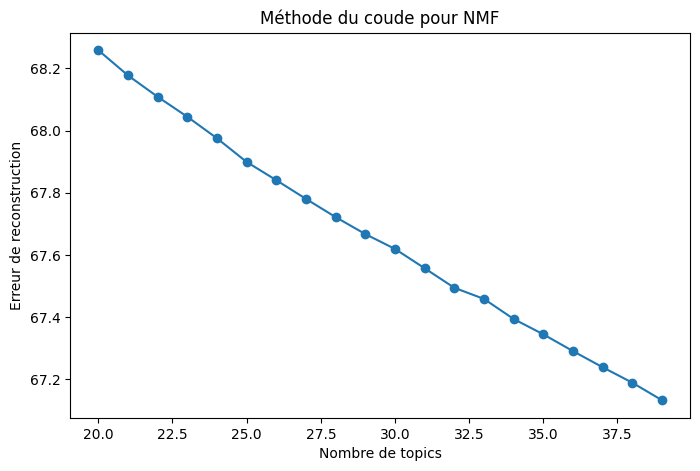

In [29]:
errors = []
k_values = range(20, 40)

for k in k_values:
    nmf = NMF(
        n_components=k,
        random_state=42,
        init="nndsvda",
        max_iter=500
    )
    
    nmf.fit(X)
    errors.append(nmf.reconstruction_err_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, errors, marker="o")
plt.xlabel("Nombre de topics")
plt.ylabel("Erreur de reconstruction")
plt.title("Méthode du coude pour NMF")
plt.show()

In [30]:
def afficher_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx+1} : {' | '.join(top_words)}")



feature_names = vectorizer.get_feature_names_out()

#for k in  [8, 10, 12, 15, 18 ]: # On teste différents nombres de topics (de 5 à 15) pour trouver le nombre optimal de topics pour notre analyse.
    
    #print(f"\n NMF avec {k} topics") 
nmf = NMF(n_components=28, 
          random_state=42,
          init="nndsvda",
          solver="cd",
          max_iter=1000,
          
            )
W = nmf.fit_transform(X)
afficher_topics(nmf, feature_names)

print("Erreur :", nmf.reconstruction_err_)

Topic 1 : main | mort | oeil | bras | sang | tête | face | lèvre | voix | corps
Topic 2 : amour | cœur | vie | jour | tendresse | bonheur | heure | heureux | joie | pensée
Topic 3 : arbre | soleil | eau | herbe | ciel | jardin | ombre | blanc | feuille | branche
Topic 4 : empereur | ministre | affaire | député | président | journal | ami | préfet | baron | politique
Topic 5 : abbé | prêtre | curé | église | jardin | trouche | soutane | sous | préfecture | évêque
Topic 6 : terre | bête | paysan | vache | coup | bon | cheval | route | cochon | vieux
Topic 7 : prussien | soldat | armée | général | route | canon | cheval | capitaine | corps | homme
Topic 8 : franc | argent | somme | billet | mois | chiffre | sou | fortune | affaire | million
Topic 9 : monsieur | dame | porte | vou | bon | air | voix | mot | tante | domestique
Topic 10 : rue | maison | quartier | trottoir | boutique | place | ville | boulevard | voiture | chaussée
Topic 11 : coupeau | maman | boutique | zingueur | blanchiss

In [39]:
W = nmf.fit_transform(X)
H = nmf.components_

df["topic_dominant"] = W.argmax(axis=1) + 1
df["score_topic_dominant"] = W.max(axis=1)

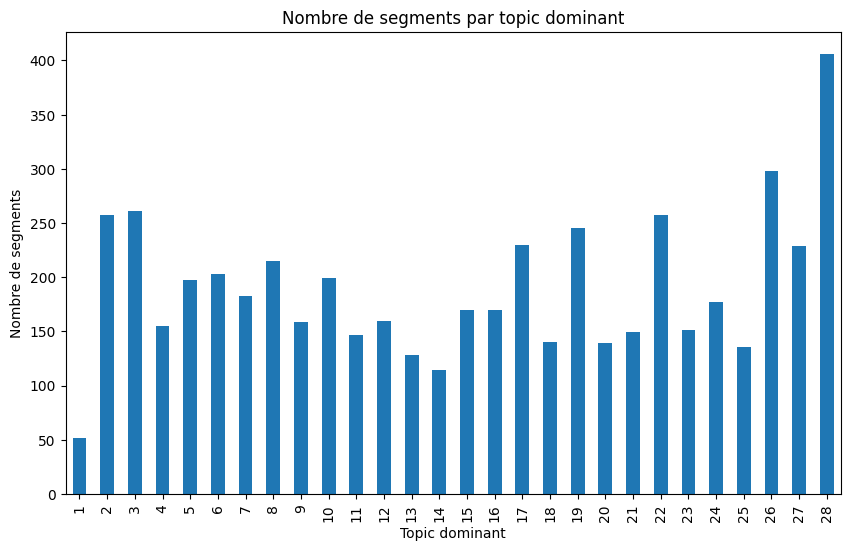

In [40]:
import matplotlib.pyplot as plt

counts = df["topic_dominant"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
counts.plot(kind="bar")

plt.title("Nombre de segments par topic dominant")
plt.xlabel("Topic dominant")
plt.ylabel("Nombre de segments")
plt.show()

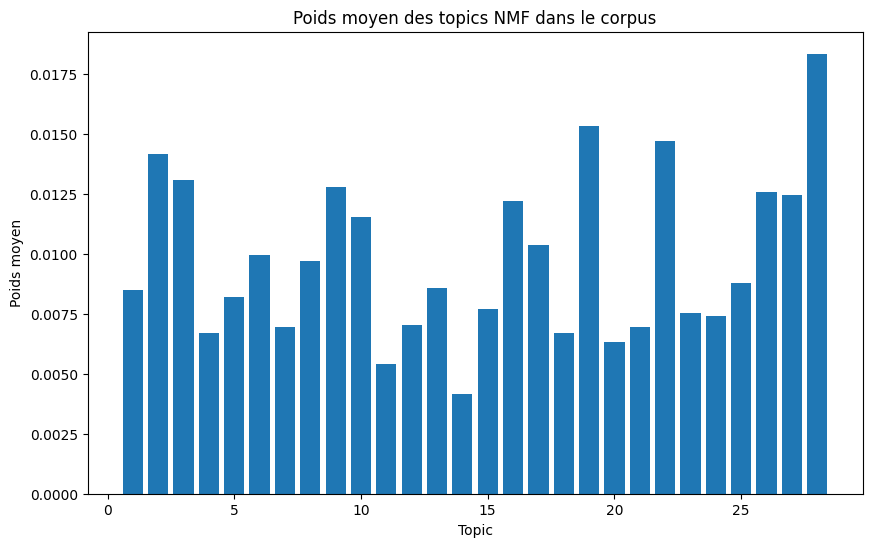

In [41]:
topic_weights = W.mean(axis=0)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(topic_weights) + 1), topic_weights)

plt.title("Poids moyen des topics NMF dans le corpus")
plt.xlabel("Topic")
plt.ylabel("Poids moyen")
plt.show()

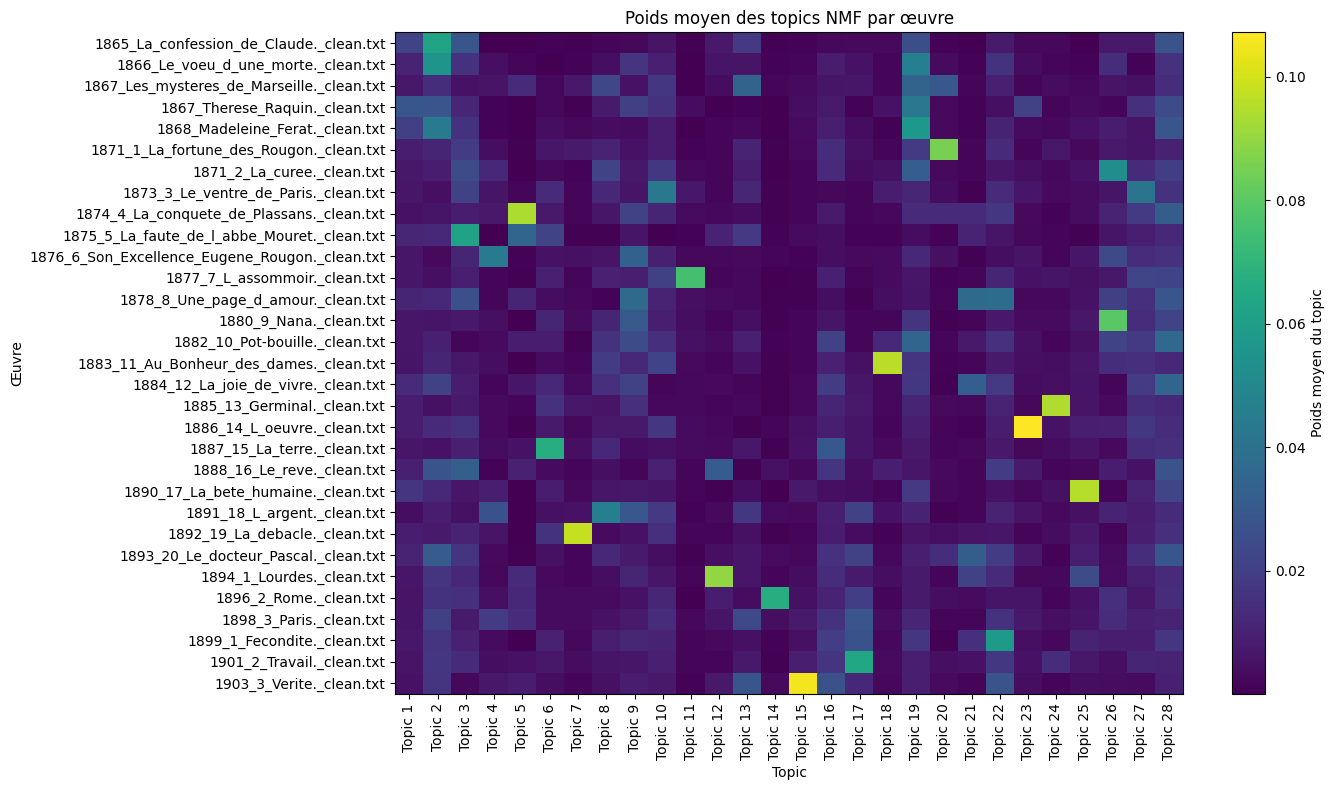

In [42]:
topics_df = pd.DataFrame(
    W,
    columns=[f"Topic {i+1}" for i in range(W.shape[1])]
)

topics_df["nom_fichier"] = df["nom_fichier"].values

table_topics = topics_df.groupby("nom_fichier").mean()

plt.figure(figsize=(14, 8))
plt.imshow(table_topics, aspect="auto")

plt.xticks(range(len(table_topics.columns)), table_topics.columns, rotation=90)
plt.yticks(range(len(table_topics.index)), table_topics.index)

plt.title("Poids moyen des topics NMF par œuvre")
plt.xlabel("Topic")
plt.ylabel("Œuvre")
plt.colorbar(label="Poids moyen du topic")
plt.tight_layout()
plt.show()

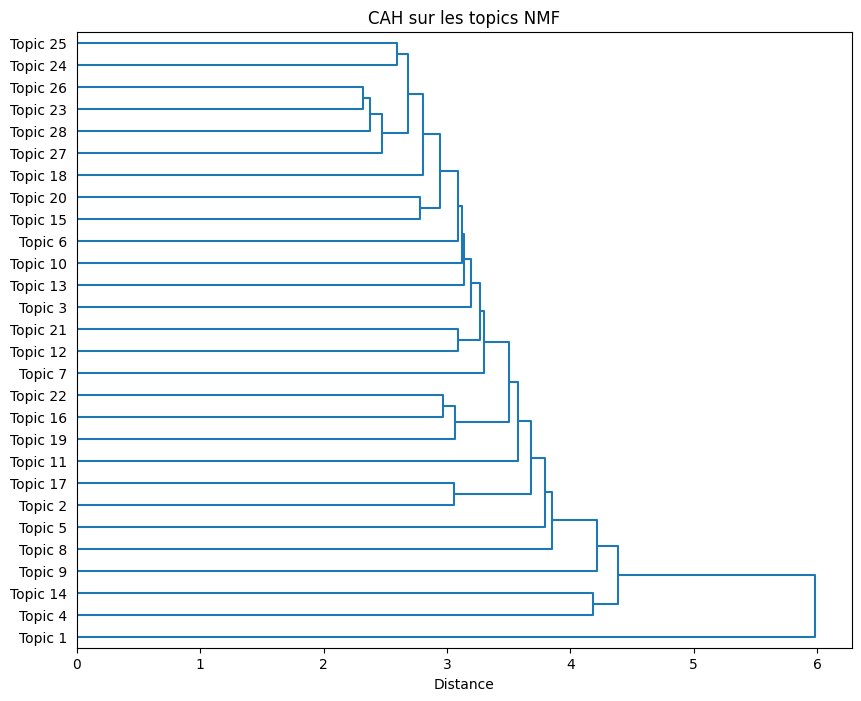

In [43]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

H = nmf.components_

Z_topics = linkage(H, method="ward")

plt.figure(figsize=(10, 8))

dendrogram(
    Z_topics,
    labels=[f"Topic {i+1}" for i in range(H.shape[0])],
    orientation="right",
    color_threshold=0.40
)

plt.title("CAH sur les topics NMF")
plt.xlabel("Distance")
plt.show()